# Data Cleaning 

In [4]:
import pandas as pd

df = pd.read_csv('../data/raw/Smart_A_S_D.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     10000 non-null  int64  
 1   timestamp                     10000 non-null  object 
 2   device_id                     10000 non-null  object 
 3   employee_id                   10000 non-null  object 
 4   department                    8233 non-null   object 
 5   shift                         8211 non-null   object 
 6   scheduled_start               9834 non-null   object 
 7   scheduled_end                 9834 non-null   object 
 8   event_type                    10000 non-null  object 
 9   fingerprint_id                10000 non-null  int64  
 10  fingerprint_match             10000 non-null  object 
 11  authentication_time_ms        10000 non-null  float64
 12  attempt_number                10000 non-null  int64  
 13  fa

In [5]:
print(df.describe())

         record_id  fingerprint_id  authentication_time_ms  attempt_number  \
count  10000.00000    10000.000000            10000.000000    10000.000000   
mean    5000.50000      848.429800              375.818580        1.193100   
std     2886.89568      393.394619              105.063912        0.474589   
min        1.00000        0.000000              150.000000        1.000000   
25%     2500.75000     1006.000000              313.475000        1.000000   
50%     5000.50000     1024.000000              354.850000        1.000000   
75%     7500.25000     1042.000000              406.400000        1.000000   
max    10000.00000     1084.000000             1354.800000        4.000000   

       failed_attempt_count_session  device_health_score  wifi_rssi_dbm  \
count                  10000.000000         10000.000000   10000.000000   
mean                       0.355400            85.543790     -57.635040   
std                        0.600106             5.891898       7.683298 

In [6]:
print(df.head())
print(df.sample(10))
print(df.shape)

   record_id            timestamp device_id employee_id       department  \
0          1  2026-05-01 03:16:45   GATE-03  UNVERIFIED              NaN   
1          2  2026-05-01 05:40:46   GATE-02       E1037       Production   
2          3  2026-05-01 05:46:13   GATE-02       E1015       Production   
3          4  2026-05-01 05:46:46   GATE-01       E1008  Quality Control   
4          5  2026-05-01 05:47:13   GATE-02       E1058      Maintenance   

     shift scheduled_start scheduled_end            event_type  \
0      NaN             NaN           NaN  Unauthorized Attempt   
1  Morning        06:00:00      14:00:00              Check-In   
2  Morning        06:00:00      14:00:00              Check-In   
3  Morning        06:00:00      14:00:00              Check-In   
4  Morning        06:00:00      14:00:00              Check-In   

   fingerprint_id  ... failed_attempt_count_session  enrollment_status  \
0               0  ...                            0                NaN  

      record_id            timestamp device_id employee_id  department  \
1205       1206  2026-05-11 22:01:15   GATE-02       E1003  Production   
6545       6546  2026-06-24 21:55:58   GATE-02       E1024  Production   
115         116  2026-05-02 05:35:52   GATE-02  UNVERIFIED         NaN   
9731       9732  2026-07-21 06:19:57   GATE-02       E1035     Packing   
1344       1345  2026-05-12 21:54:44   GATE-02  UNVERIFIED         NaN   
5167       5168  2026-06-13 06:04:15   GATE-02       E1057     Packing   
6541       6542  2026-06-24 21:53:07   GATE-02       E1013    Security   
7072       7073  2026-06-29 13:31:40   GATE-01  UNVERIFIED         NaN   
4193       4194  2026-06-05 05:58:01   GATE-02       E1028  Production   
7037       7038  2026-06-28 14:07:07   GATE-01       E1042    Security   

          shift scheduled_start scheduled_end            event_type  \
1205  Afternoon        14:00:00      22:00:00             Check-Out   
6545      Night        22:00:00      06:00:

In [7]:
df.isnull().sum()


record_id                          0
timestamp                          0
device_id                          0
employee_id                        0
department                      1767
shift                           1789
scheduled_start                  166
scheduled_end                    166
event_type                         0
fingerprint_id                     0
fingerprint_match                  0
authentication_time_ms             0
attempt_number                     0
failed_attempt_count_session       0
enrollment_status               9968
is_late                            0
is_early_exit                      0
device_status                      0
device_health_score                0
wifi_rssi_dbm                      0
system_uptime_hr                   0
database_sync_status               0
alert_type                      7148
dtype: int64

In [9]:
import pandas as pd

df = pd.read_csv('../data/raw/Smart_A_S_D.csv')

df['department'].fillna(df['department'].mode()[0], inplace=True)
df['shift'].fillna(df['shift'].mode()[0], inplace=True)
df['enrollment_status'].fillna(df['enrollment_status'].mode()[0], inplace=True)
df['alert_type'].fillna(df['alert_type'].mode()[0], inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_2672\1473524283.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['department'].fillna(df['department'].mode()[0], inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_2672\1473524283.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [10]:
df.isnull().sum()

record_id                         0
timestamp                         0
device_id                         0
employee_id                       0
department                        0
shift                             0
scheduled_start                 166
scheduled_end                   166
event_type                        0
fingerprint_id                    0
fingerprint_match                 0
authentication_time_ms            0
attempt_number                    0
failed_attempt_count_session      0
enrollment_status                 0
is_late                           0
is_early_exit                     0
device_status                     0
device_health_score               0
wifi_rssi_dbm                     0
system_uptime_hr                  0
database_sync_status              0
alert_type                        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

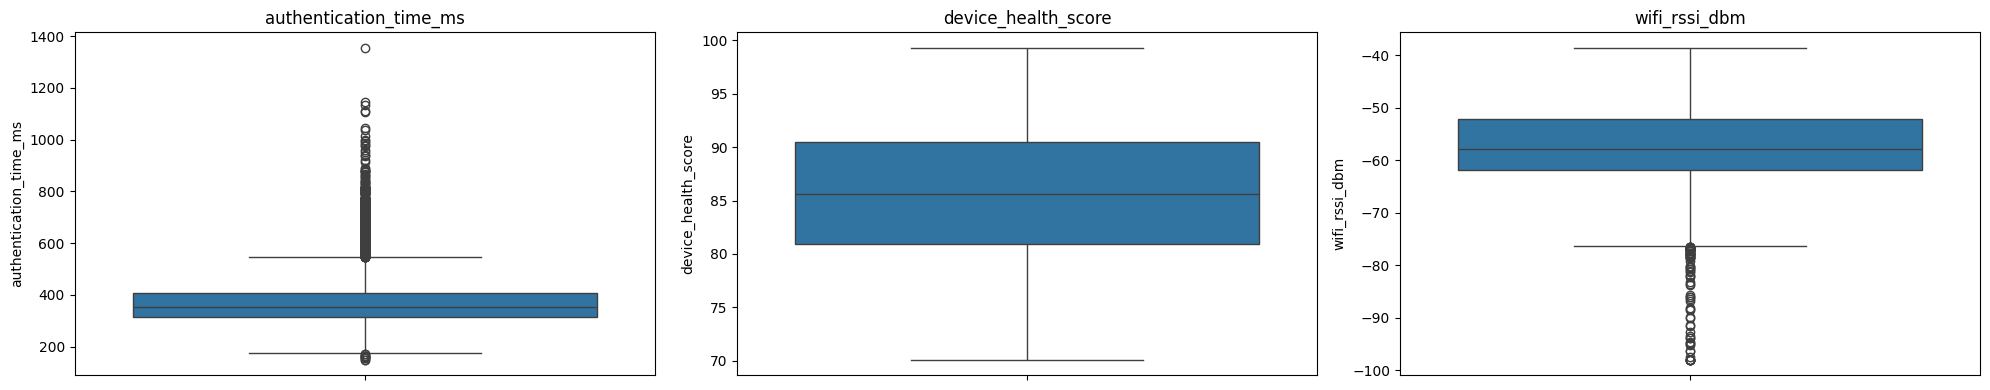

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['authentication_time_ms',  'device_health_score', 'wifi_rssi_dbm']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [13]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | bounds ({lower:.2f}, {upper:.2f})")
    return outliers

for col in numeric_cols:
    find_outliers_iqr(df, col)

authentication_time_ms: 770 outliers | bounds (174.09, 545.79)
device_health_score: 0 outliers | bounds (66.50, 104.90)
wifi_rssi_dbm: 84 outliers | bounds (-76.45, -37.65)


In [19]:
df.info()
df.describe()
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Row count:", len(df))


df.to_csv('../data/proccesed/cleaned_data.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     10000 non-null  int64  
 1   timestamp                     10000 non-null  object 
 2   device_id                     10000 non-null  object 
 3   employee_id                   10000 non-null  object 
 4   department                    10000 non-null  object 
 5   shift                         10000 non-null  object 
 6   scheduled_start               9834 non-null   object 
 7   scheduled_end                 9834 non-null   object 
 8   event_type                    10000 non-null  object 
 9   fingerprint_id                10000 non-null  int64  
 10  fingerprint_match             10000 non-null  object 
 11  authentication_time_ms        10000 non-null  float64
 12  attempt_number                10000 non-null  int64  
 13  fa

Pearson Coorelation 


It measures linear relationship between two 

* features snd is used for coorelation between continuos numerical variables and is used when the data is normally distributed.

* When the relationship has a certain plateau after having rapid rise in their values pearson method fails.

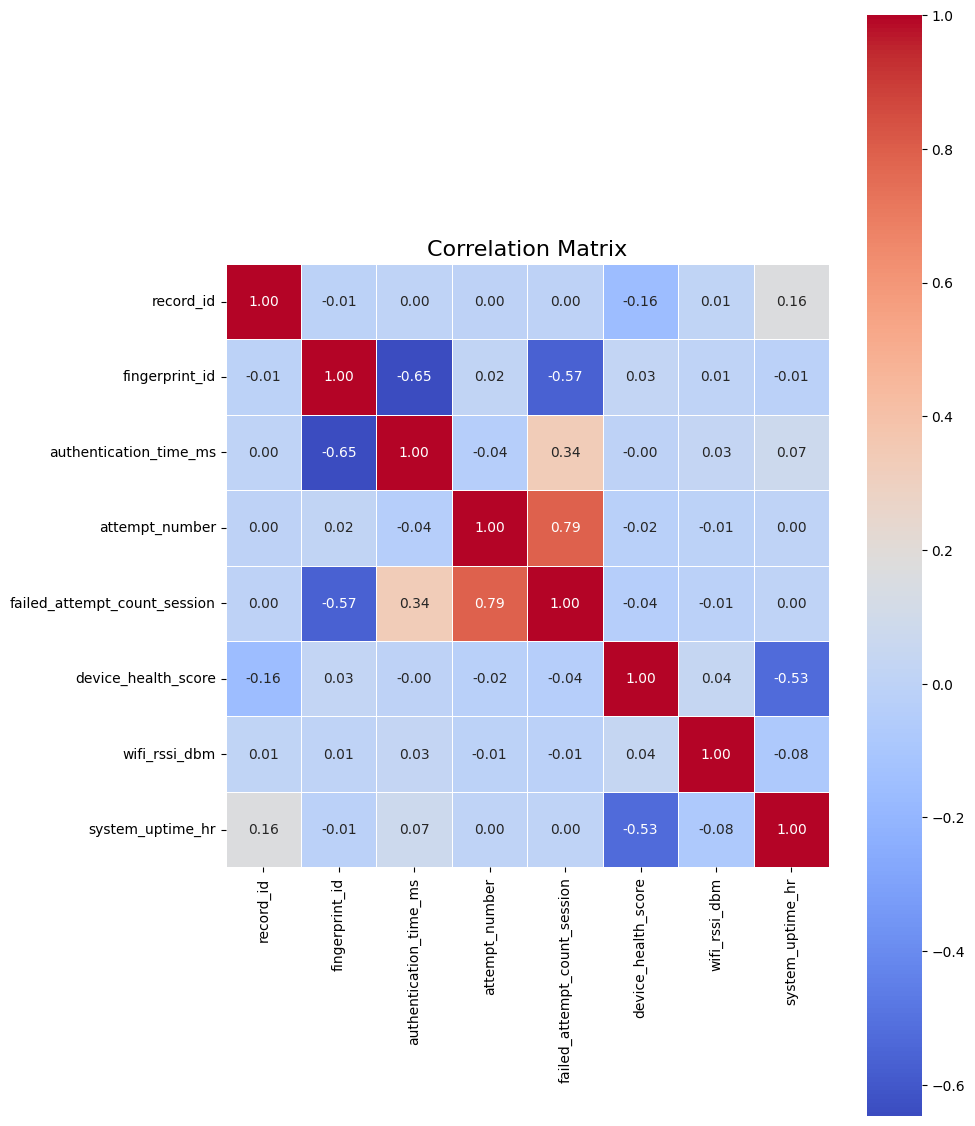

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr(method ='pearson')

# Plot heatmap
plt.figure(figsize=(10, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation values
    fmt=".2f",           # Show values with 2 decimal places
    cmap="coolwarm",     # Blue (-1) to Red (+1)
    linewidths=0.5,      # Lines between cells
    square=True,         # Make each cell square
    cbar=True            # Show color bar
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

sPearman Coorelation 


It measures monotonic relationship between two 
features snd is used for comparing values or ranks, it coorelates the ranks or the features.It is used when their is ordinals data ranked data and nwhen outliers ar3 present and where there 

it is not affected by outliers

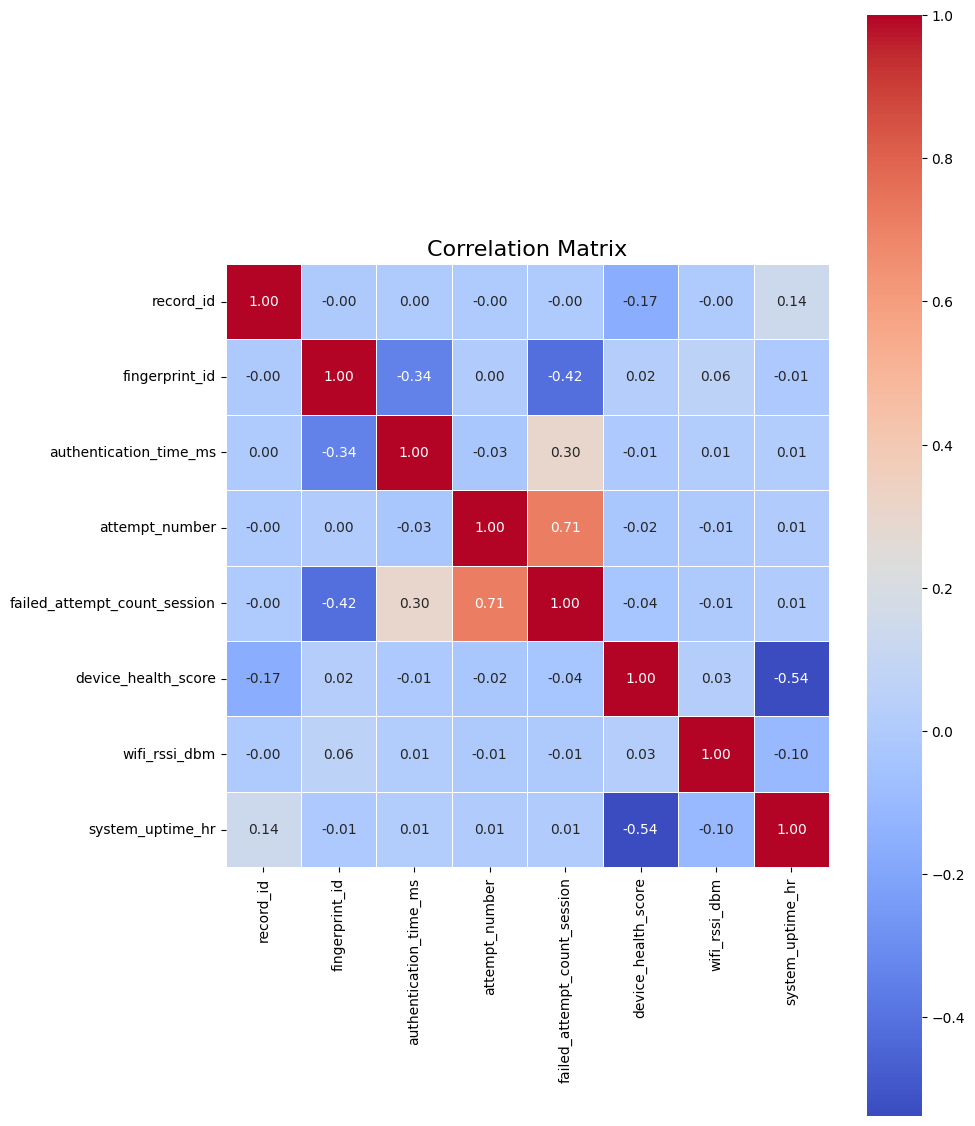

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr(method ='spearman')

# Plot heatmap
plt.figure(figsize=(10, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation values
    fmt=".2f",           # Show values with 2 decimal places
    cmap="coolwarm",     # Blue (-1) to Red (+1)
    linewidths=0.5,      # Lines between cells
    square=True,         # Make each cell square
    cbar=True            # Show color bar
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()